In [97]:
import pandas
import os

In [98]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_vehicules = []

for year in years:
    df_vehicules_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"vehicules-{year}.csv"), encoding="utf-8", sep = ";")
    df_vehicules.append(df_vehicules_year)

df_vehicules = pandas.concat(df_vehicules)
df_vehicules

,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc
0,201900000001,138 306 524,B01,2,7,0,2,5,23,1,NaN
1,201900000001,138 306 525,A01,2,17,1,0,3,11,1,NaN
2,201900000002,138 306 523,A01,1,7,4,0,1,0,1,NaN
3,201900000003,138 306 520,A01,1,7,0,2,1,2,1,NaN
4,201900000003,138 306 521,B01,1,7,1,0,4,2,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
92673,202400054401,155 686 119,Y01,1,60,1,2,7,0,5,NaN
92674,202400054401,155 686 120,A01,1,33,1,2,1,1,1,NaN
92675,202400054402,155 686 118,A01,1,10,0,2,1,2,1,NaN
92676,202400054402,155 686 121,B01,1,7,0,2,4,2,1,NaN


In [99]:
# First we are dropping features that we are not going to use: num_veh as we will use id_vehicule instead
df_vehicules.drop(columns = ['num_veh', 'senc', 'occutc'], inplace = True)

In [100]:
df_vehicules["id_vehicule"] = (
    df_vehicules["id_vehicule"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)  # keep only digits
    .astype("int64")
)

In [101]:
df_vehicules.replace(-1, pandas.NA, inplace=True)
df_vehicules.isna().sum()

# Removing rows with missing values
df_vehicules = df_vehicules.dropna()

In [102]:
# And converting to int
cols_small_int = ['catv', 'obs', 'obsm', 'choc', 'manv', 'motor']
df_vehicules[cols_small_int] = df_vehicules[cols_small_int].astype("int64")

In [103]:
# Grouping too specific categories of vehicule into more broad types:
vehicle_group_map = {
    # other / unknown
    0: 0,
    99: 0,

    # bicycles
    1: 1,

    # motorcycles / 2-3 wheels
    2: 2,
    4: 2,
    5: 2,
    6: 2,
    30: 2,
    31: 2,
    32: 2,
    33: 2,
    34: 2,
    35: 2,
    36: 2,
    41: 2,
    42: 2,
    43: 2,

    # cars
    3: 3,
    7: 3,
    8: 3,
    9: 3,

    # light utility vehicles
    10: 4,
    11: 4,
    12: 4,

    # trucks / heavy vehicles
    13: 5,
    14: 5,
    15: 5,
    16: 5,
    17: 5,

    # public transport
    18: 6,
    19: 6,
    37: 6,
    38: 6,

    # agricultural / special machinery
    20: 7,
    21: 7,

    # rail vehicles
    39: 6,
    40: 6,

    # micromobility
    50: 8,
    60: 8,
    80: 8
}

df_vehicules["catv"] = df_vehicules["catv"].map(vehicle_group_map)

In [104]:
obs_group_map = {
    0: 0,

    1: 1,

    # rigid obstacles
    2: 2,
    6: 2,

    # barriers
    3: 3,
    4: 3,
    5: 3,

    # roadside objects
    7: 4,
    8: 4,
    9: 4,

    # road infrastructure
    10: 5,
    11: 5,
    12: 5,

    # terrain
    13: 6,
    17: 6,

    # other obstacles
    14: 7,
    15: 7,

    16: 8
}

df_vehicules["obs"] = df_vehicules["obs"].map(obs_group_map)

In [105]:
maneuver_group_map = {
    0: 0,

    # straight movement
    1: 1,
    2: 1,

    # lane change / lateral movement
    3: 2,
    11: 2,
    12: 2,
    13: 2,
    14: 2,

    # turning
    15: 3,
    16: 3,

    # overtaking
    17: 4,
    18: 4,

    # crossing / entering road
    9: 5,
    10: 5,
    19: 5,

    # abnormal directions
    4: 6,
    5: 6,
    6: 6,

    # stopped / parking
    20: 7,
    23: 7,
    24: 7,

    # avoidance
    21: 8,

    # door
    22: 9,

    # sidewalk
    25: 10,

    # bus lane
    7: 11,
    8: 11,

    # other
    26: 12
}

df_vehicules["manv"] = df_vehicules["manv"].map(maneuver_group_map)

In [106]:
features = ['catv', 'obs', 'obsm', 'choc', 'manv', 'motor']

In [107]:
df_vehicules_analyse = df_vehicules.copy()

mapping = {
    0: "other / unknown",
    1: "bicycles",
    2: "motorcycles / 2-3 wheels",
    3: "cars",
    4: "light utility vehicles",
    5: "trucks / heavy vehicles",
    6: "public transport",
    7: "agricultural / special machinery",
    8: "rail vehicles",
    9: "micromobility"
}

df_vehicules_analyse["catv"]= df_vehicules_analyse["catv"].replace(mapping)

mapping = {
    0: "no_obstacle",
    1: "parked_vehicle",
    2: "rigid_structure",
    3: "safety_barrier",
    4: "roadside_object",
    5: "road_infrastructure",
    6: "terrain",
    7: "other_obstacle",
    8: "road_departure"
}

df_vehicules_analyse["obs"]= df_vehicules_analyse["obs"].replace(mapping)

mapping = {
0 : "Aucun" ,   
1 : "Piéton" ,  
2 : "Véhicule"  ,
4 : "Véhicule sur rail"  ,
5 : "Animal domestique"  ,
6 : "Animal sauvage"  ,
9 : "Autre"  
}

df_vehicules_analyse["obsm"]= df_vehicules_analyse["obsm"].replace(mapping)

mapping = {
0 : "Aucun" ,   
1 : "Avant"   ,
2 : "Avant droit" ,  
3 : "Avant gauche"  ,
4 : "Arrière" ,  
5 : "Arrière droit" ,  
6 : "Arrière gauche" ,  
7 : "Côté droit"  ,
8 : "Côté gauche" , 
9 : "Chocs multiples (tonneaux)" 
}

df_vehicules_analyse["choc"]= df_vehicules_analyse["choc"].replace(mapping)

mapping = {
    0: "unknown",
    1: "straight",
    2: "lane_change",
    3: "turning",
    4: "overtaking",
    5: "crossing_inserting",
    6: "abnormal_direction",
    7: "stopped_or_parking",
    8: "avoidance",
    9: "door_opening",
    10: "sidewalk",
    11: "bus_lane",
    12: "other"
}

df_vehicules_analyse["manv"]= df_vehicules_analyse["manv"].replace(mapping)

mapping = {
0 : "Inconnue" ,   
1 : "Hydrocarbures" ,   
2 : "Hybride électrique" ,  
3 : "Electrique" , 
4 : "Hydrogène"  ,
5 : "Humaine" ,  
6 : "Autre" 
}

df_vehicules_analyse["motor"] = df_vehicules_analyse["motor"].replace(mapping)

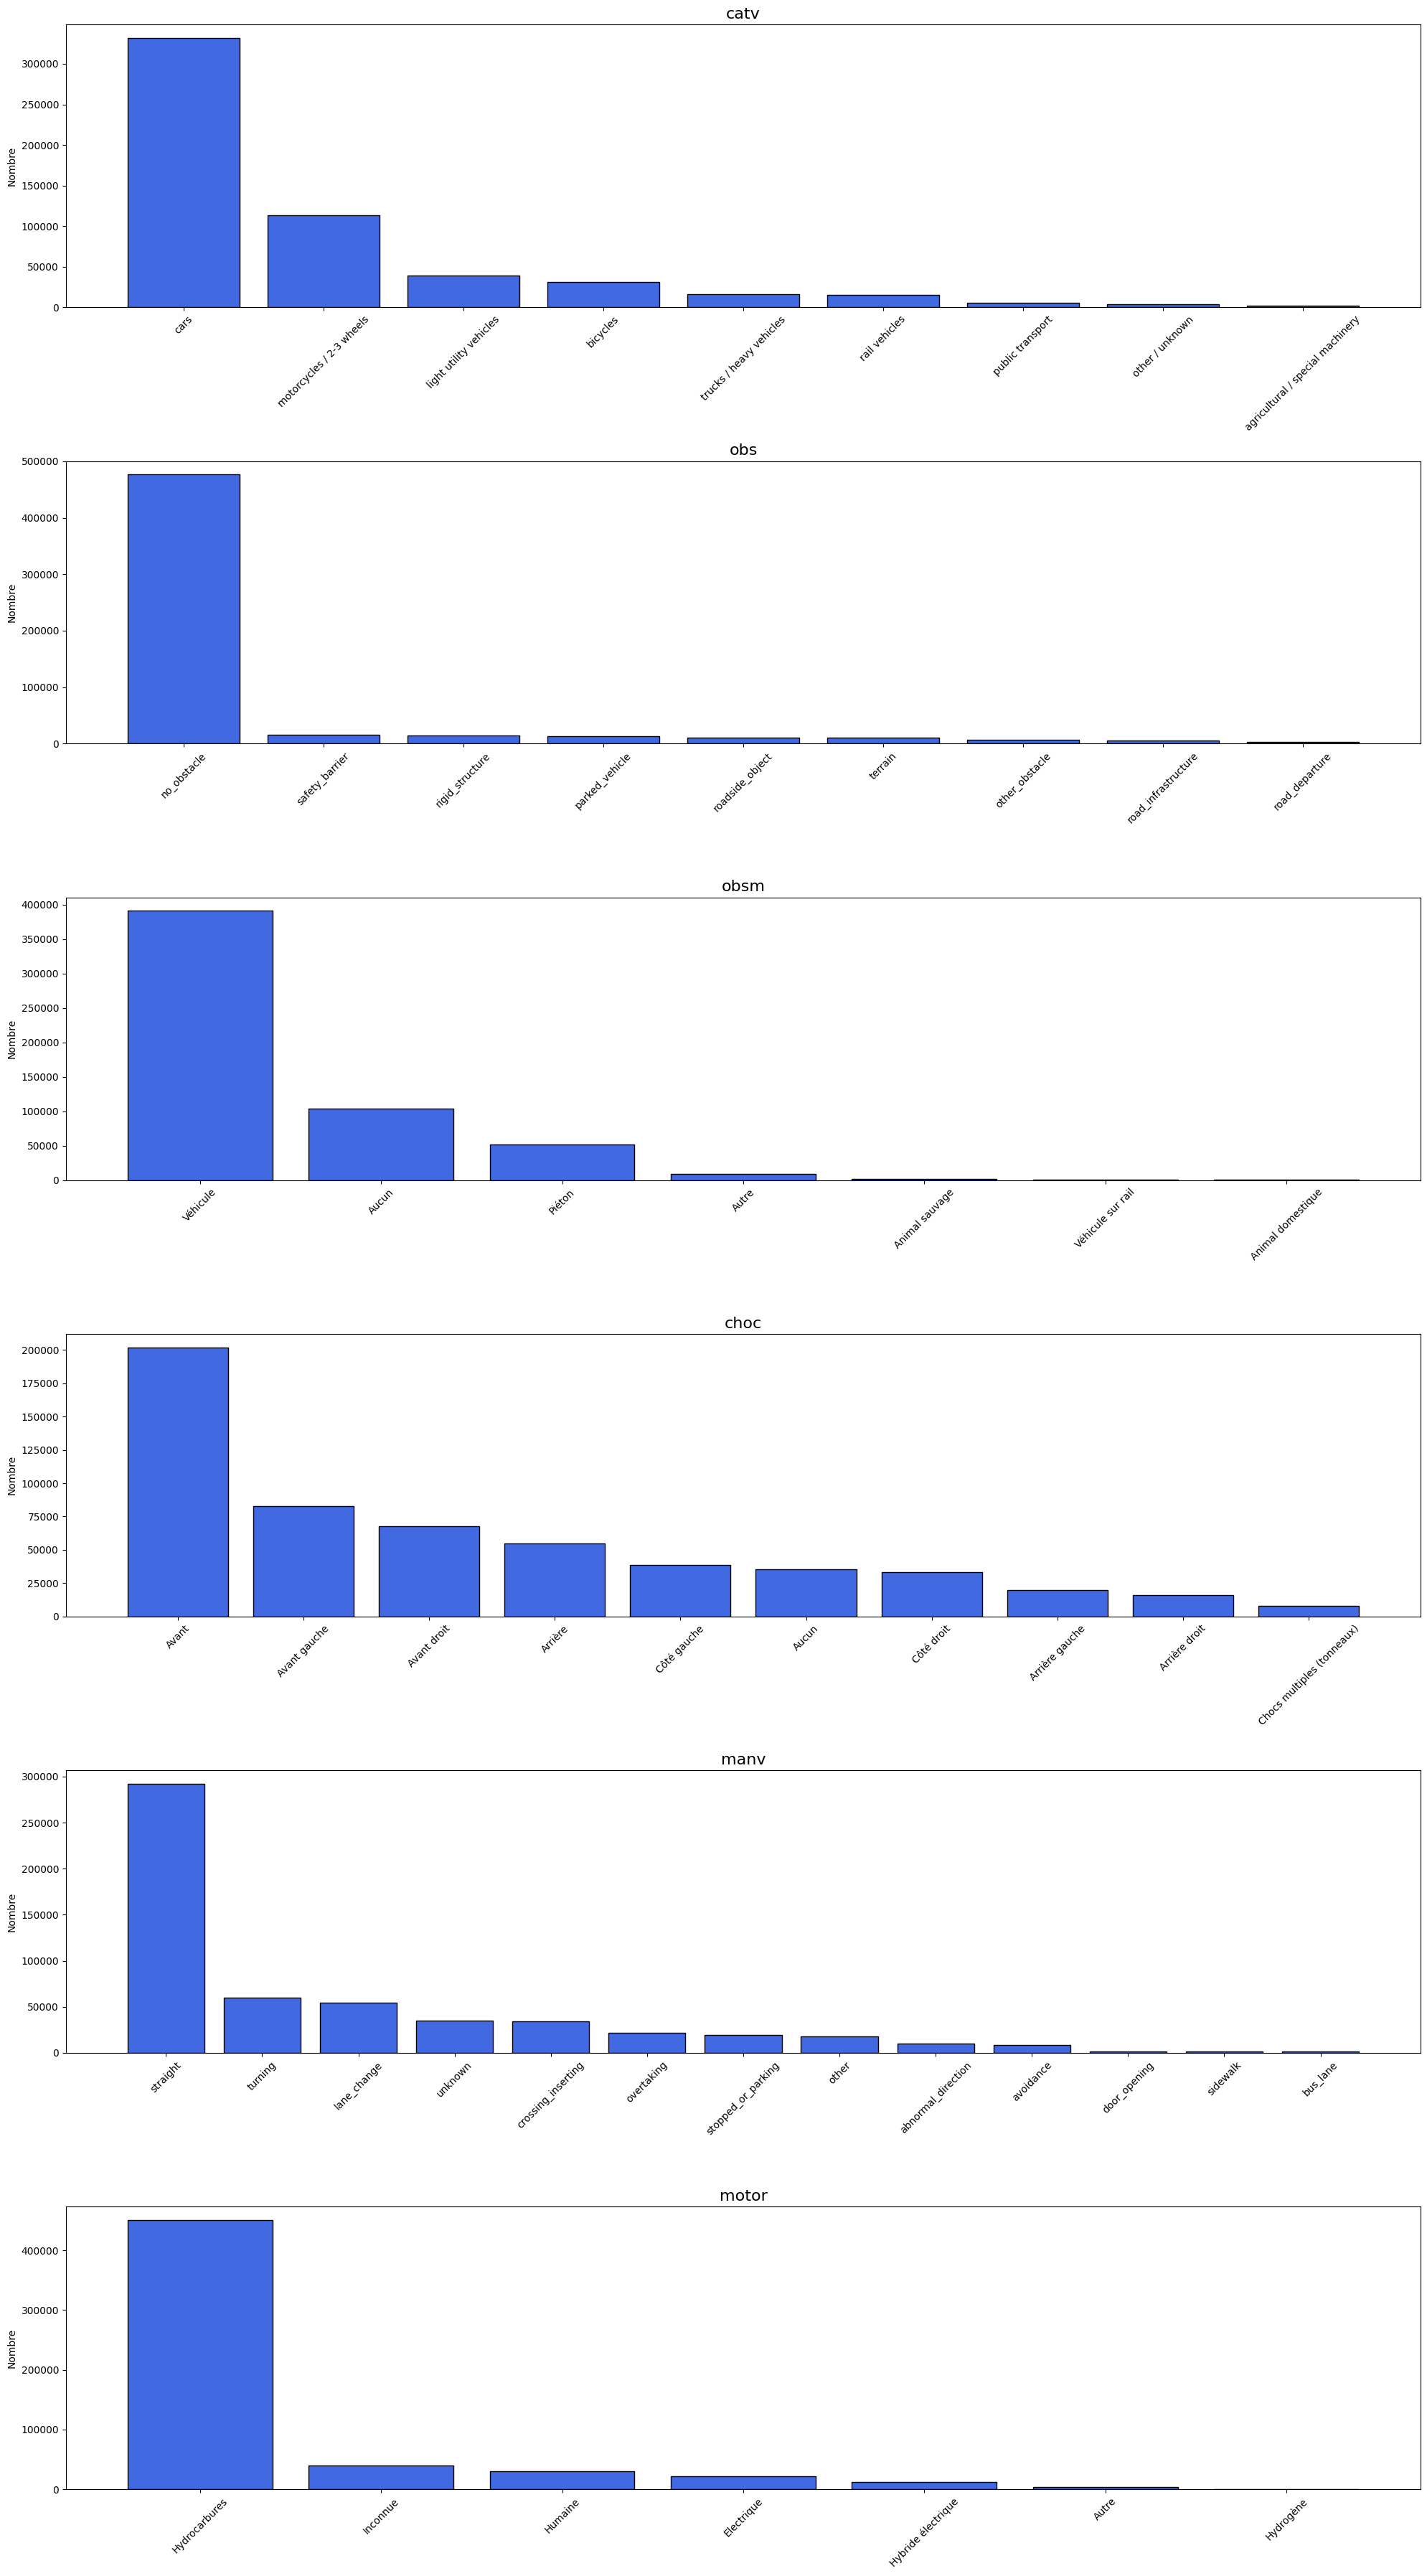

In [108]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(len(features), 1, figsize=(20, 6*len(features)))

for i, feature in enumerate(features):
    values = df_vehicules_analyse[feature]
    counts = values.value_counts()
    
    ax[i].bar(counts.index.astype(str), counts.values, color="royalblue", edgecolor="black")
    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Nombre")

plt.tight_layout()

In [109]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

In [110]:
df_vehicules_with_target = df_vehicules.merge(
    df_usagers[['Num_Acc', 'grav_bin']],
    on='Num_Acc',
    how='left'
)
target = "grav_bin"

In [111]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = pandas.get_dummies(df_vehicules_with_target[features], drop_first=True) # treat the as categories
y = df_vehicules_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

importances = pandas.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

obs      0.255759
obsm     0.215402
choc     0.184692
manv     0.158415
catv     0.130077
motor    0.055655
dtype: float64


In [112]:
from sklearn.feature_selection import mutual_info_classif

X = pandas.get_dummies(df_vehicules_with_target[features], drop_first=True)
y = df_vehicules_with_target[target]

mi = mutual_info_classif(X, y)

pandas.Series(mi, index=X.columns).sort_values(ascending=False)

obsm     0.144121
catv     0.112119
motor    0.098823
manv     0.036862
choc     0.032951
obs      0.012334
dtype: float64

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X = pandas.get_dummies(df_vehicules_with_target[features], drop_first=True)
y = df_vehicules_with_target[target] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    # "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [114]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


 Logistic Regression
Accuracy: 0.8437040068348087
              precision    recall  f1-score   support

           0       0.84      1.00      0.92    235036
           1       0.00      0.00      0.00     43538

    accuracy                           0.84    278574
   macro avg       0.42      0.50      0.46    278574
weighted avg       0.71      0.84      0.77    278574


 Decision Tree
Accuracy: 0.8457896286085564
              precision    recall  f1-score   support

           0       0.85      0.99      0.92    235036
           1       0.54      0.08      0.14     43538

    accuracy                           0.85    278574
   macro avg       0.70      0.53      0.53    278574
weighted avg       0.80      0.85      0.79    278574


 Gradient Boosting
Accuracy: 0.8465147501202553
              precision    recall  f1-score   support

           0       0.85      0.99      0.92    235036
           1       0.61      0.05      0.09     43538

    accuracy                         

AUC of Logistic Regression: 0.601
AUC of Decision Tree: 0.668
AUC of Gradient Boosting: 0.662


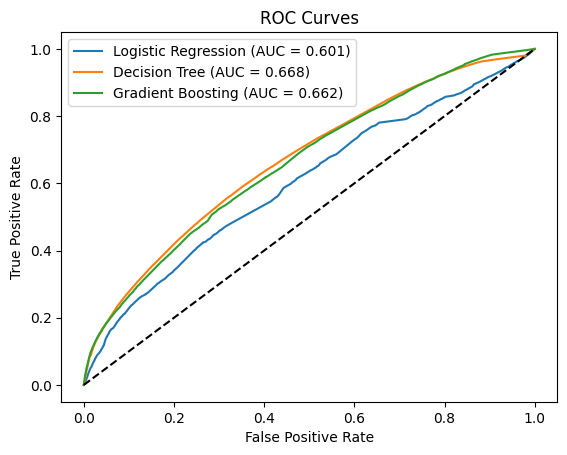

In [115]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

lst_auc = []

for name, model in models.items():

    y_proba = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [116]:
# Finally we are going to save the dataset cleaned
df_vehicules.to_csv("df_vehicules_clean.csv", index=False)

In [117]:
df_vehicules = pandas.read_csv("df_vehicules_clean.csv")

In [118]:
print("All columns:", df_vehicules.columns)
print("Features:", features)

All columns: Index(['Num_Acc', 'id_vehicule', 'catv', 'obs', 'obsm', 'choc', 'manv',
       'motor'],
      dtype='str')
Features: ['catv', 'obs', 'obsm', 'choc', 'manv', 'motor']
